# 02 — Exploratory Data Analysis

Loads `df_development` from `data/processed/` (produced by `01_data_loading_cleaning.ipynb`) and covers:

- Suicide rate evolution by country and by EU region
- Cross-country distribution
- Feature distributions and skewness
- Outlier detection (IQR)
- Multicollinearity check (VIF) and the resulting drop of `Eating disorders`

In [1]:
import sys

sys.path.append("..")

import pandas as pd

from src import (
    ID_COLS,
    TARGET,
    EU_REGIONS,
    SOCIAL_ECONOMIC_FEATURES,
    compute_vif,
    flag_outliers_iqr,
    build_predictor_list,
    suicide_evolution_graph,
    plot_suicide_trend_by_region,
    plot_suicide_boxplot_by_country,
    plot_feature_distributions,
    plot_suicide_dispersion_stripplot,
    plot_vif_bar,
    save_figure,
)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

df_development = pd.read_parquet("../data/processed/df_development.parquet")
print(
    f"df_development: {df_development.shape[0]} rows, {df_development.shape[1]} columns"
)
display(df_development.head())

fig_prefix = "02_"

df_development: 594 rows, 23 columns


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.280000,423.2,17.383069


## Suicide rate evolution — country spotlights

Highest and lowest average suicide rate in the EU (Lithuania and Greece), plus Germany as a mid-range reference. This gives context for the outliers that are formally flagged later in the notebook — a country sitting far from the EU average is not automatically a data error.

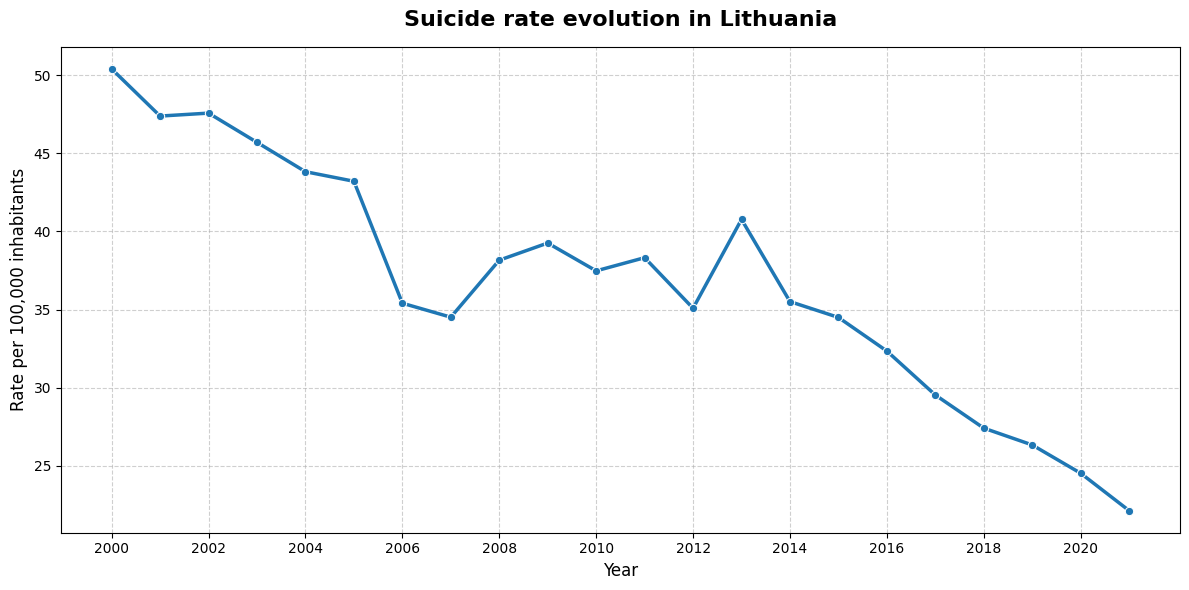

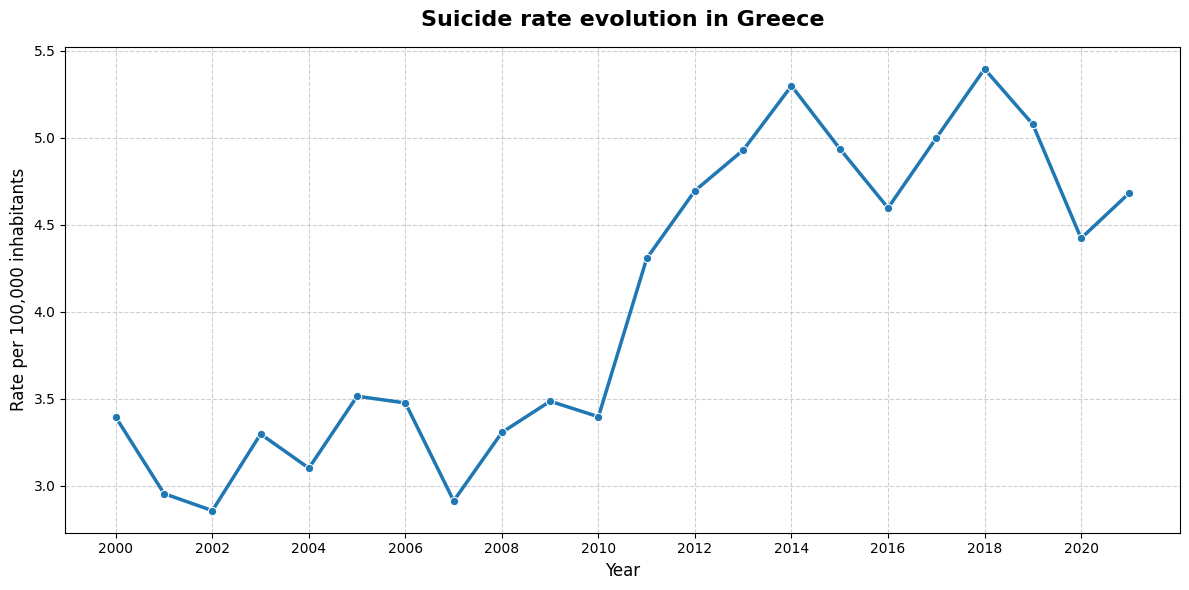

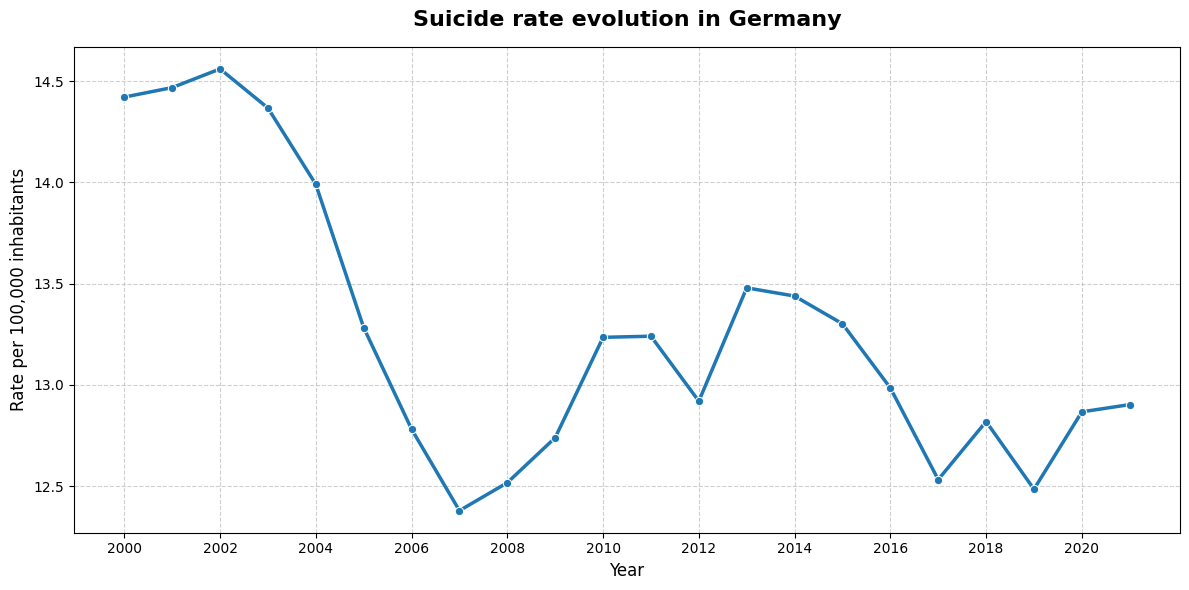

In [2]:
fig = suicide_evolution_graph(df_development, "LTU", "Lithuania")  # highest average
path = save_figure(fig, name="suicide_evolution_ltu", prefix=fig_prefix)
fig = suicide_evolution_graph(df_development, "GRC", "Greece")  # lowest average
path = save_figure(fig, name="suicide_evolution_grc", prefix=fig_prefix)
fig = suicide_evolution_graph(df_development, "DEU", "Germany")  # mid-range reference
path = save_figure(fig, name="suicide_evolution_deu", prefix=fig_prefix)

## Suicide rate trends by EU region (2000-2021)

Countries are grouped into four regions (`EU_REGIONS` in `src/config.py`: Western Europe/Nordics, Mediterranean, Eastern Europe, Baltics) based on geographic and cultural proximity rather than any statistical clustering. The idea is to check whether suicide rate trends move together within these informal groupings — which would suggest shared structural factors (history, culture, healthcare system design) beyond what the individual socioeconomic indicators capture.

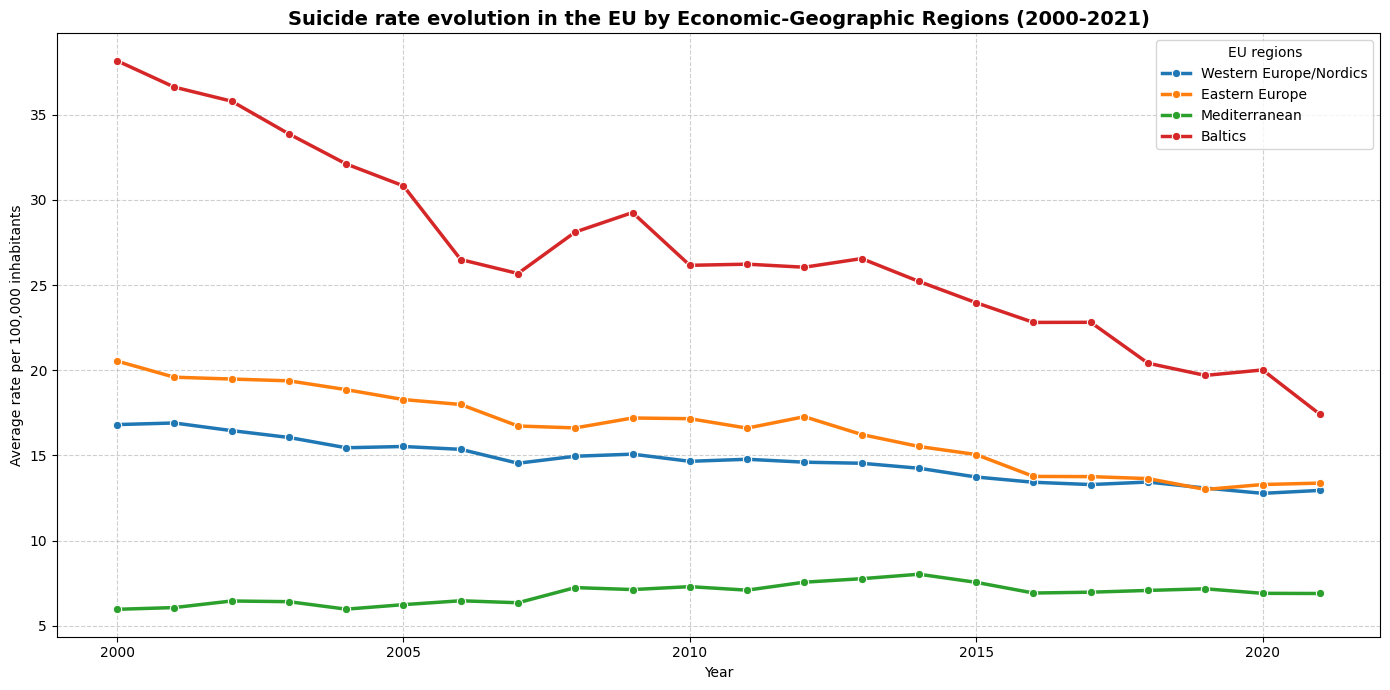

In [3]:
df_development["Region"] = df_development["Code"].map(EU_REGIONS)
fig = plot_suicide_trend_by_region(df_development)
path = save_figure(fig, name="suicide_trend_by_region", prefix=fig_prefix)

## Cross-country distribution analysis

Boxplot of the full suicide rate distribution per country (2000–2021), ordered by median. This complements the three country spotlights above by showing the spread and overlap across *all* 27 countries at once, rather than just three examples.

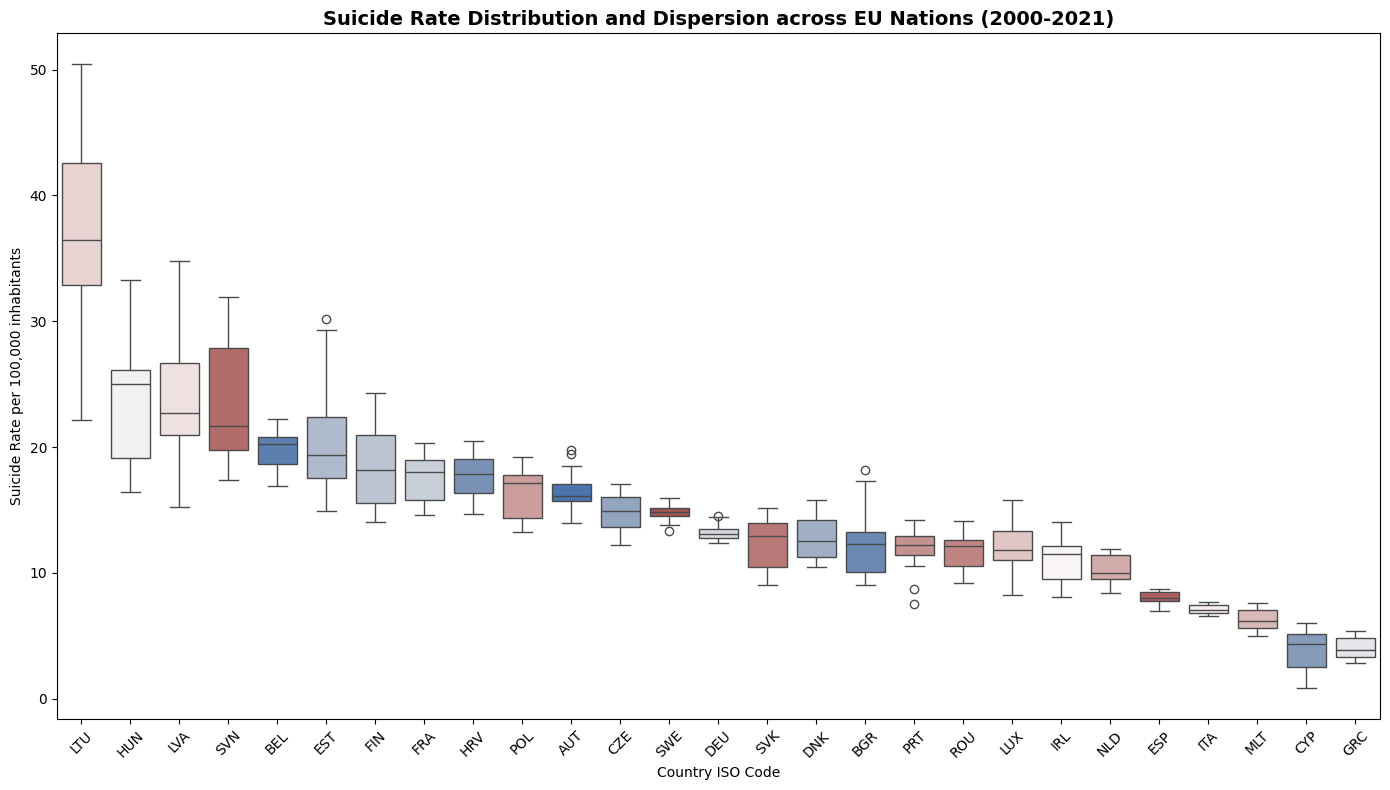

In [4]:
fig = plot_suicide_boxplot_by_country(df_development)
path = save_figure(fig, name="suicide_boxplot_by_country", prefix=fig_prefix)

## Feature distribution analysis

Histograms + KDE for all numerical predictors, annotated with skewness. Beyond describing the data, this matters for two decisions made later: heavily skewed features can distort linear models (Ridge/Lasso) more than tree-based ones, and skew driven by extreme values is part of the motivation for using `RobustScaler` (median/IQR-based) instead of a mean-based `StandardScaler` when scaling for modelling in `03_models.ipynb`.


Skewness summary:
Population                                  1.82
GDP per capita                              1.70
Unemployment rate (%)                       1.48
Alzheimer's disease and other dementias     1.33
Anxiety disorders                           1.26
Physicians per 100000                       1.24
Depressive disorders                        0.95
Drug use disorders                          0.82
Attention-deficit/hyperactivity disorder    0.73
Conduct disorder                            0.66
Autism spectrum disorders                   0.32
Health expenditure (% GDP)                  0.18
Bipolar disorder                            0.18
Urban population (%)                        0.16
Gini index                                  0.11
Eating disorders                            0.03
Alcohol use disorders                      -0.04
Schizophrenia                              -0.04
Internet users (% of population)           -0.65
dtype: float64


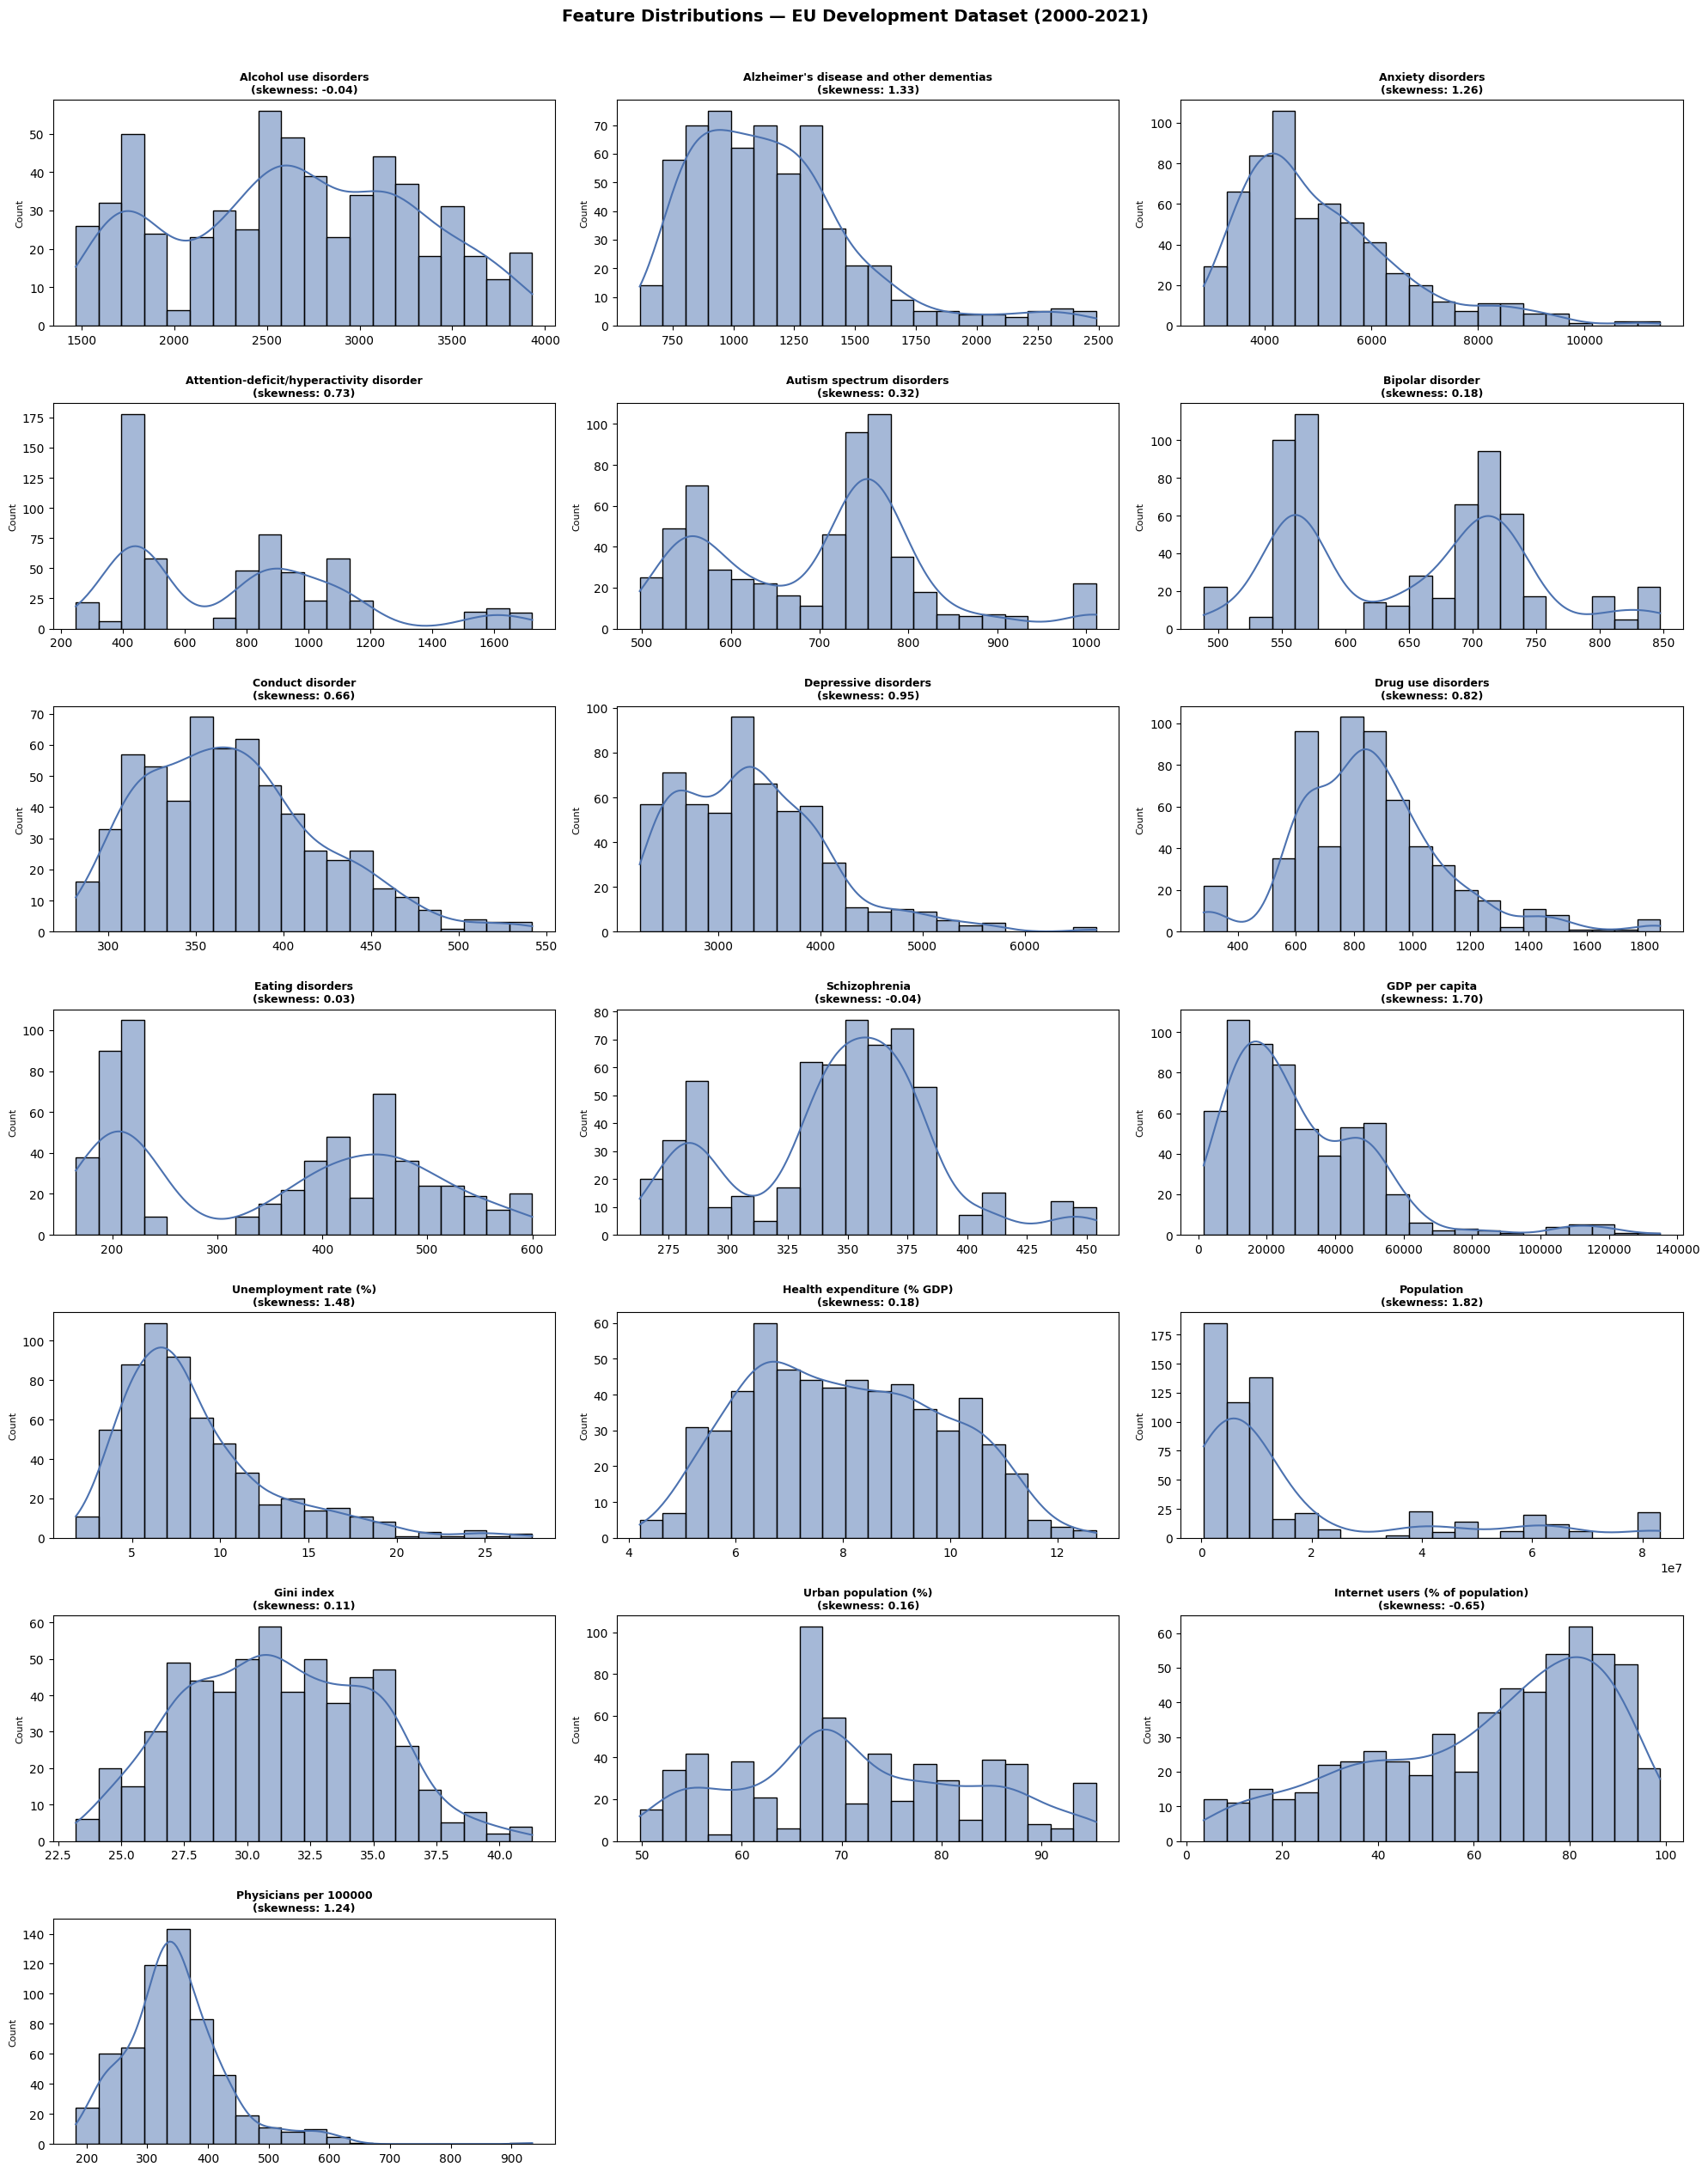

In [5]:
predictor_features = build_predictor_list(df_development, ID_COLS, TARGET)

fig = plot_feature_distributions(df_development, predictor_features)
path = save_figure(fig, name="feature_distributions", prefix=fig_prefix)

print("\nSkewness summary:")
print(df_development[predictor_features].skew().sort_values(ascending=False).round(2))

## Outlier detection (IQR method)

Flags values falling outside `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` for each socioeconomic feature independently. These outliers are **flagged for awareness, not removed** — some of them are genuine (e.g. a country with an unusually high Gini index), and removing them would throw away real signal. This is also why `RobustScaler`, rather than outlier removal, is the chosen way of handling them during modelling.

Outlier Summary (IQR method, threshold=1.5):


,Feature,Outlier count,Outlier %,Lower bound,Upper bound
4,Population,110,18.52,-16125106.75,35771617.25
2,Unemployment rate (%),31,5.22,-1.35,17.25
6,Physicians per 100000,26,4.38,163.24,517.34
0,Suicide rate,23,3.87,-2.05,30.30
1,GDP per capita,18,3.03,-28443.29,85443.25
3,Health expenditure (% GDP),0,0.00,2.28,13.70
5,Urban population (%),0,0.00,36.69,106.22
7,Gini index,0,0.00,19.50,42.86
8,Internet users (% of population),0,0.00,-13.00,140.16


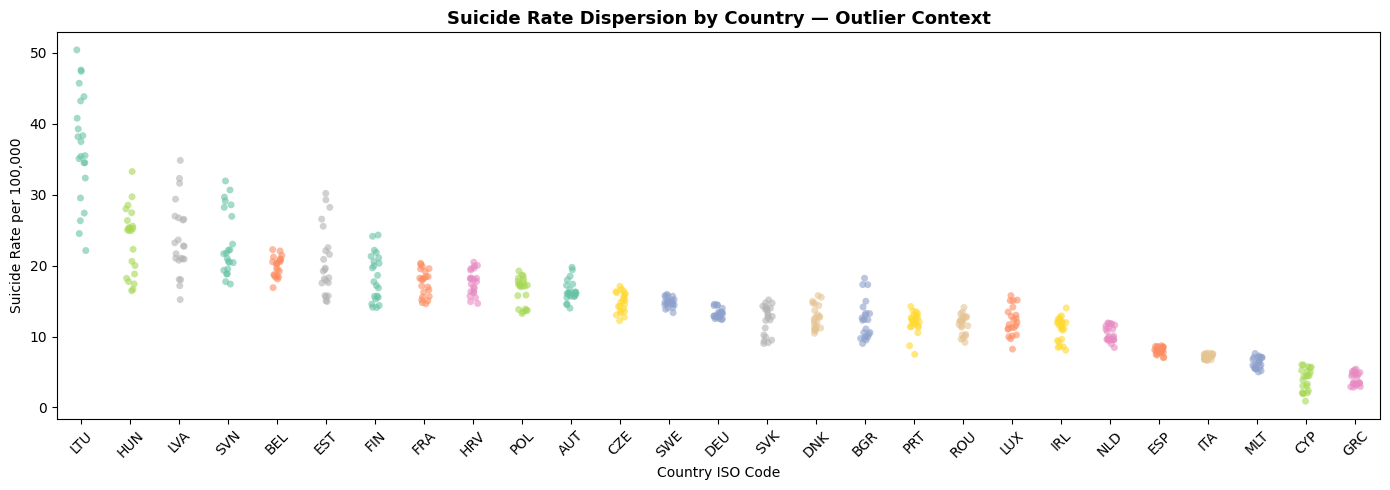

In [6]:
socioeconomic_cols_for_outliers = [
    c for c in SOCIAL_ECONOMIC_FEATURES if c in df_development.columns
]

outlier_summary = flag_outliers_iqr(df_development, socioeconomic_cols_for_outliers)
print("Outlier Summary (IQR method, threshold=1.5):")
display(outlier_summary)

fig = plot_suicide_dispersion_stripplot(df_development)
path = save_figure(fig, name="suicide_dispersion_stripplot", prefix=fig_prefix)

## Multicollinearity check (VIF)

The Variance Inflation Factor quantifies how much the variance of a feature's estimated coefficient is inflated because that feature is linearly predictable from the other predictors. VIF > 5: moderate concern; VIF > 10: high concern — at that point the feature is carrying mostly redundant information rather than independent signal, which destabilises linear model coefficients.

Variance Inflation Factor (VIF) — full predictor set:


,Feature,VIF
0,Eating disorders,12.098098
1,Attention-deficit/hyperactivity disorder,6.083566
2,Autism spectrum disorders,5.789782
3,GDP per capita,5.704804
4,Alzheimer's disease and other dementias,3.932540
5,Health expenditure (% GDP),3.771981
6,Bipolar disorder,3.649573
7,Urban population (%),3.101839
8,Internet users (% of population),3.085974
9,Conduct disorder,2.910188


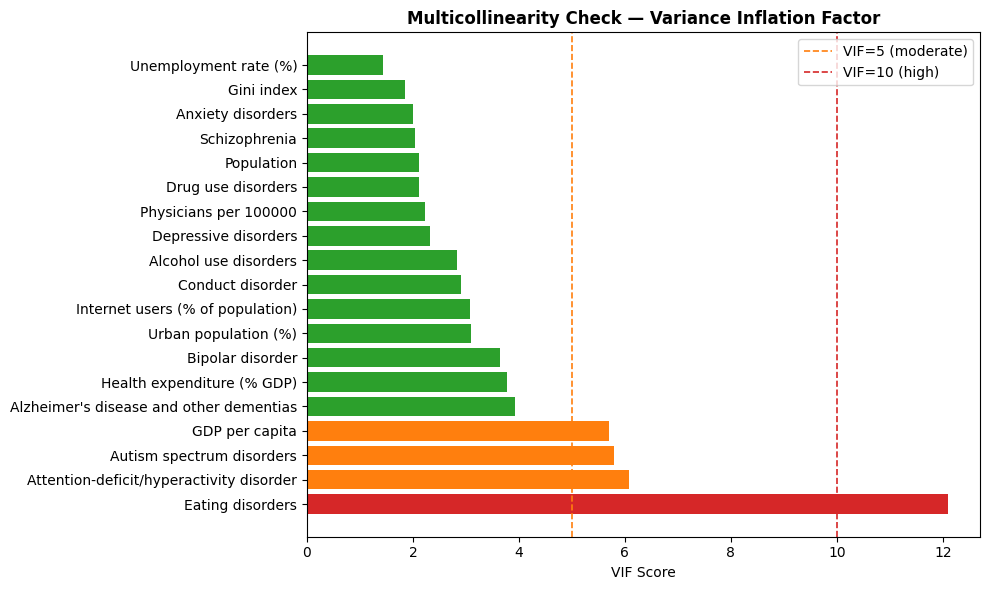

In [7]:
vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) — full predictor set:")
display(vif_results)
fig = plot_vif_bar(vif_results)
path = save_figure(fig, name="vif_bar", prefix=fig_prefix)

### Addressing high multicollinearity: dropping `Eating disorders`

`Eating disorders` has a VIF of 12.098 (see `src/config.py`) — high enough that it shares most of its variance with the other mental-health predictors and adds almost no independent information to the model. It is dropped before modelling, and VIF is recomputed on the reduced predictor set to confirm the remaining features are within acceptable bounds.

Variance Inflation Factor (VIF) — after dropping Eating disorders:


,Feature,VIF
0,Autism spectrum disorders,5.009035
1,Attention-deficit/hyperactivity disorder,4.621890
2,Alzheimer's disease and other dementias,3.893506
3,Health expenditure (% GDP),3.771978
4,GDP per capita,3.287560
5,Urban population (%),3.096490
6,Conduct disorder,2.903915
7,Internet users (% of population),2.903730
8,Bipolar disorder,2.867534
9,Alcohol use disorders,2.693740


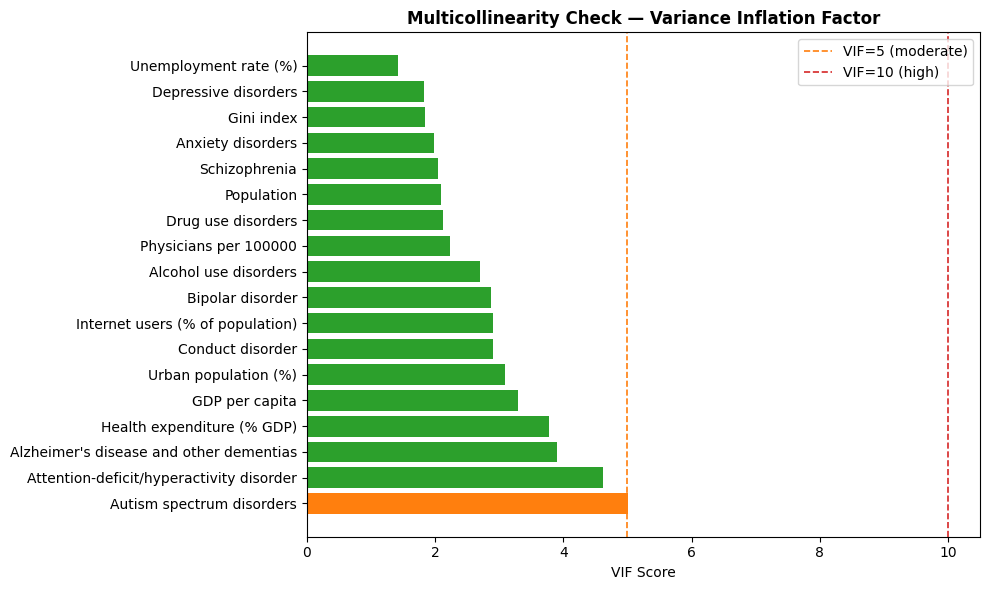

In [8]:
df_development = df_development.drop(columns=["Eating disorders"], errors="ignore")
predictor_features = build_predictor_list(df_development, ID_COLS, TARGET)

vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) — after dropping Eating disorders:")
display(vif_results)
fig = plot_vif_bar(vif_results)
path = save_figure(fig, name="vif_bar", prefix=fig_prefix)

## Save EDA-cleaned dataset

Overwrites `df_development.parquet` with `Region` added and `Eating disorders` dropped, so downstream notebooks pick up both changes.

In [9]:
df_development.to_parquet("../data/processed/df_development.parquet", index=False)
print("Saved: data/processed/df_development.parquet (updated)")

Saved: data/processed/df_development.parquet (updated)
